# Fase 3 — Inteligencia de Negocios (BI)
La fase 3 toma como entrada el dataset ya limpio y enriquecido por la fase 2
(`students_model_ready.csv`, 50.000 filas × 26 columnas) y lo transforma en un
**modelo dimensional analítico** apto para alimentar un tablero ejecutivo.

## Por qué un modelo dimensional y no la tabla cruda

Una tabla de 26 columnas mezcla en el mismo nivel cosas muy distintas:
identificación, métricas de rendimiento, hábitos de uso, percepciones,
políticas, codificaciones. Para BI esto es contraproducente porque:

- Mezcla **hechos** (cosas medibles, aditivas, que cambian semestre a semestre,
  como el GPA o la retención) con **atributos descriptivos** (carrera, política
  institucional) que no se suman.
- Hace difícil filtrar y agregar: si un analista quiere "promedio de cambio de
  GPA por carrera y nivel de uso de IA" sobre la tabla cruda, debe acordarse
  de qué columnas son cuáles.
- Mata el rendimiento: con un esquema estrella las dimensiones quedan pequeñas
  y la herramienta de BI las puede cachear, mientras que la tabla cruda se
  recorre completa cada vez.

El esquema estrella resuelve esto separando **lo que se mide** de **por dónde
se quiere ver lo que se mide**.


## 0. Configuración e importación de librerías

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

ROOT = ".."
SRC  = os.path.join(ROOT, "data", "processed", "students_model_ready.csv")
BI   = os.path.join(ROOT, "data", "bi")
OUT  = os.path.join(ROOT, "reports", "bi")
os.makedirs(BI,  exist_ok=True)
os.makedirs(OUT, exist_ok=True)
print("Rutas listas")

Rutas listas


## 1. Carga del dataset procesado

Tomamos como punto de partida `students_model_ready.csv`, que sale de la fase
de ETL (notebook `01_etl.ipynb`). Este archivo ya tiene:

- 50.000 estudiantes únicos, sin duplicados ni nulos.
- Las cinco variables derivadas: `Cambio_GPA`, `Nivel_Uso_IA`,
  `Dependencia_Alta`, `Estudio_Total` y `Riesgo_Academico`.
- Encodings ordinales para las variables que tienen orden natural:
  `Year_Encoded`, `Prompt_Skill_Encoded`, `Policy_Encoded`, `Burnout_Encoded`,
  `Uso_IA_Encoded`.

No se hace ninguna transformación adicional en esta fase: BI consume datos ya
limpios, esa es la frontera con la fase 2.

In [2]:
df = pd.read_csv(SRC)
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head(3)

Filas: 50,000  |  Columnas: 26


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Cambio_GPA,Nivel_Uso_IA,Dependencia_Alta,Estudio_Total,Riesgo_Academico,Year_Encoded,Prompt_Skill_Encoded,Policy_Encoded,Burnout_Encoded,Uso_IA_Encoded
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,Alto,0,31.44,1,4,1,1,2,2
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,Bajo,0,17.77,0,3,3,1,0,0
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,Alto,0,31.61,0,1,1,0,1,2


## 2. Diseño del modelo dimensional

### 2.1 Granularidad
La pregunta clave en cualquier modelo de BI es **¿qué representa una fila de
la tabla de hechos?** Aquí la respuesta es:

> Una fila de FACT_ESTUDIANTE = un estudiante en un semestre.

Esto significa que todas las métricas (Pre_GPA, Post_GPA, Cambio_GPA,
Retención, Riesgo, Estudio_Total) están a esa granularidad y se pueden
agregar libremente: sumar, promediar, contar, filtrar por dimensión.

### 2.2 Tablas del esquema

| Tabla | Tipo | Filas | Para qué sirve |
|---|---|---|---|
| `FACT_ESTUDIANTE` | Hechos | 50.000 | Métricas medibles, claves foráneas |
| `DIM_PERFIL` | Dimensión | 50.000 | Carrera, año, habilidad de prompting |
| `DIM_USO_IA` | Dimensión | 50.000 | Horas, caso de uso, diversidad, suscripción |
| `DIM_INSTITUCION` | Dimensión | 3 | Política institucional |
| `DIM_BIENESTAR` | Dimensión | 50.000 | Burnout, dependencia, ansiedad |

### 2.3 ¿Por qué tres dimensiones quedan en 50.000 filas?
Cada estudiante reporta una combinación única de horas, dependencia y burnout,
así que estas dimensiones son "1-a-1" con el estudiante. En un proyecto
operativo de Data Warehouse podríamos deduplicar, pero en analítica vale más
la pena conservar el detalle: nos permite filtrar por cualquier combinación
de atributos sin perder granularidad.

`DIM_INSTITUCION` sí es una dimensión clásica de baja cardinalidad (3 niveles
de política: Strict_Ban, Allowed_With_Citation, Actively_Encouraged), porque
solo existen tres regímenes regulatorios distintos en todo el dataset.

## 3. Construcción de las dimensiones

### 3.1 DIM_INSTITUCION

Es la dimensión más pequeña y la más interesante desde el punto de vista de
política pública. La construimos con `drop_duplicates` y le añadimos una
descripción humana para que el dashboard pueda mostrar tooltips legibles.

In [3]:
dim_inst = (df[["Institutional_Policy", "Policy_Encoded"]]
            .drop_duplicates()
            .sort_values("Policy_Encoded")
            .reset_index(drop=True))
dim_inst.insert(0, "institucion_id", range(1, len(dim_inst)+1))
dim_inst["Descripcion_Politica"] = dim_inst["Institutional_Policy"].map({
    "Strict_Ban":            "Prohibición total del uso de IA en trabajos académicos",
    "Allowed_With_Citation": "Uso permitido siempre que se cite la herramienta",
    "Actively_Encouraged":   "Uso fomentado activamente como parte del proceso",
})
dim_inst

,institucion_id,Institutional_Policy,Policy_Encoded,Descripcion_Politica
0,1,Strict_Ban,0,Prohibición total del uso de IA en trabajos ac...
1,2,Allowed_With_Citation,1,Uso permitido siempre que se cite la herramienta
2,3,Actively_Encouraged,2,Uso fomentado activamente como parte del proceso


### 3.2 DIM_PERFIL - perfil académico

Aquí van los atributos que describen *quién es* el estudiante en términos
académicos: a qué área pertenece, en qué año va y qué tan bueno es formulando
prompts. Nada de esto cambia semana a semana, por eso es dimensión y no
hecho.

In [4]:
dim_perfil = df[[
    "Student_ID", "Major_Category",
    "Year_of_Study", "Year_Encoded",
    "Prompt_Engineering_Skill", "Prompt_Skill_Encoded",
]].copy()
dim_perfil.insert(0, "perfil_id", dim_perfil["Student_ID"])
print(f"DIM_PERFIL: {len(dim_perfil):,} filas")
dim_perfil.head(3)

DIM_PERFIL: 50,000 filas


,perfil_id,Student_ID,Major_Category,Year_of_Study,Year_Encoded,Prompt_Engineering_Skill,Prompt_Skill_Encoded
0,100001,100001,Humanities,Senior,4,Beginner,1
1,100002,100002,Medical,Junior,3,Advanced,3
2,100003,100003,Business,Freshman,1,Beginner,1


### 3.3 DIM_USO_IA - hábitos de uso

Cada estudiante usa la IA de forma propia: cuántas horas, para qué, cuántas
herramientas, si paga o no. Todo eso son atributos descriptivos del *hábito*
de uso, no métricas de resultado.

In [5]:
dim_uso = df[[
    "Student_ID", "Weekly_GenAI_Hours", "Nivel_Uso_IA", "Uso_IA_Encoded",
    "Primary_Use_Case", "Tool_Diversity", "Paid_Subscription",
    "Traditional_Study_Hours",
]].copy()
dim_uso.insert(0, "uso_ia_id", dim_uso["Student_ID"])
print(f"DIM_USO_IA: {len(dim_uso):,} filas")
dim_uso.head(3)

DIM_USO_IA: 50,000 filas


,uso_ia_id,Student_ID,Weekly_GenAI_Hours,Nivel_Uso_IA,Uso_IA_Encoded,Primary_Use_Case,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours
0,100001,100001,23.31,Alto,2,Copywriting/Drafting,1,1,8.13
1,100002,100002,1.12,Bajo,0,Ideation,5,0,16.65
2,100003,100003,21.26,Alto,2,Summarizing_Reading,2,0,10.35


### 3.4 DIM_BIENESTAR - salud mental y dependencia

Aquí viven las variables blandas pero críticas: nivel de burnout, dependencia
percibida y ansiedad durante exámenes. Si en un futuro la institución añade
encuestas de bienestar más detalladas, ese contenido se agregaría aquí sin
tocar las demás tablas.

In [6]:
dim_bien = df[[
    "Student_ID", "Burnout_Risk_Level", "Burnout_Encoded",
    "Perceived_AI_Dependency", "Dependencia_Alta",
    "Anxiety_Level_During_Exams",
]].copy()
dim_bien.insert(0, "bienestar_id", dim_bien["Student_ID"])
print(f"DIM_BIENESTAR: {len(dim_bien):,} filas")
dim_bien.head(3)

DIM_BIENESTAR: 50,000 filas


,bienestar_id,Student_ID,Burnout_Risk_Level,Burnout_Encoded,Perceived_AI_Dependency,Dependencia_Alta,Anxiety_Level_During_Exams
0,100001,100001,High,2,5,0,6
1,100002,100002,Low,0,3,0,9
2,100003,100003,Medium,1,5,0,9


## 4. Construcción de la tabla de hechos

Las métricas que se quieren agregar y graficar quedan aquí. Cada fila lleva,
además, las claves foráneas que apuntan a sus cuatro dimensiones.

In [7]:
mapa_inst = dict(zip(dim_inst["Institutional_Policy"], dim_inst["institucion_id"]))

fact = pd.DataFrame({
    "Student_ID":            df["Student_ID"],
    "Pre_Semester_GPA":      df["Pre_Semester_GPA"],
    "Post_Semester_GPA":     df["Post_Semester_GPA"],
    "Cambio_GPA":            df["Cambio_GPA"],
    "Skill_Retention_Score": df["Skill_Retention_Score"],
    "Riesgo_Academico":      df["Riesgo_Academico"],
    "Estudio_Total":         df["Estudio_Total"],
    "perfil_id":             df["Student_ID"],
    "uso_ia_id":             df["Student_ID"],
    "bienestar_id":          df["Student_ID"],
    "institucion_id":        df["Institutional_Policy"].map(mapa_inst),
})
# Validación de integridad referencial
assert fact[["perfil_id","uso_ia_id","bienestar_id","institucion_id"]].isna().sum().sum() == 0
print(f"FACT_ESTUDIANTE: {len(fact):,} filas — sin claves foráneas nulas")
fact.head(3)

FACT_ESTUDIANTE: 50,000 filas — sin claves foráneas nulas


,Student_ID,Pre_Semester_GPA,Post_Semester_GPA,Cambio_GPA,Skill_Retention_Score,Riesgo_Academico,Estudio_Total,perfil_id,uso_ia_id,bienestar_id,institucion_id
0,100001,2.418,2.393,-0.025,86.44,1,31.44,100001,100001,100001,2
1,100002,3.821,3.696,-0.125,69.39,0,17.77,100002,100002,100002,2
2,100003,3.398,3.499,0.101,73.93,0,31.61,100003,100003,100003,1


## 5. Persistencia del esquema estrella

Guardamos las cinco tablas en `data/bi/` para que el dashboard, otros
notebooks y herramientas externas (Power BI, Tableau, Looker) puedan
conectarse a ellas directamente.

In [8]:
dim_inst.to_csv(  os.path.join(BI, "DIM_INSTITUCION.csv"), index=False)
dim_perfil.to_csv(os.path.join(BI, "DIM_PERFIL.csv"),       index=False)
dim_uso.to_csv(   os.path.join(BI, "DIM_USO_IA.csv"),       index=False)
dim_bien.to_csv(  os.path.join(BI, "DIM_BIENESTAR.csv"),    index=False)
fact.to_csv(      os.path.join(BI, "FACT_ESTUDIANTE.csv"),  index=False)
print("Tablas guardadas en", BI)

Tablas guardadas en ../data/bi


## 6. Vista unificada para el análisis

Para calcular KPIs y graficar es más cómodo trabajar con una vista ya
"joineada". En SQL sería:

```sql
SELECT *
FROM fact_estudiante f
JOIN dim_perfil       p ON f.perfil_id      = p.perfil_id
JOIN dim_uso_ia       u ON f.uso_ia_id      = u.uso_ia_id
JOIN dim_bienestar    b ON f.bienestar_id   = b.bienestar_id
JOIN dim_institucion  i ON f.institucion_id = i.institucion_id;
```

En pandas, lo mismo con `.merge()`:

In [9]:
v = (fact
     .merge(dim_perfil.drop(columns=["Student_ID"]), on="perfil_id")
     .merge(dim_uso.drop(columns=["Student_ID"]),    on="uso_ia_id")
     .merge(dim_bien.drop(columns=["Student_ID"]),   on="bienestar_id")
     .merge(dim_inst, on="institucion_id"))
print("Vista unificada:", v.shape)
v.head(2)

Vista unificada: (50000, 31)


,Student_ID,Pre_Semester_GPA,Post_Semester_GPA,Cambio_GPA,Skill_Retention_Score,Riesgo_Academico,Estudio_Total,perfil_id,uso_ia_id,bienestar_id,institucion_id,Major_Category,Year_of_Study,Year_Encoded,Prompt_Engineering_Skill,Prompt_Skill_Encoded,Weekly_GenAI_Hours,Nivel_Uso_IA,Uso_IA_Encoded,Primary_Use_Case,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Burnout_Risk_Level,Burnout_Encoded,Perceived_AI_Dependency,Dependencia_Alta,Anxiety_Level_During_Exams,Institutional_Policy,Policy_Encoded,Descripcion_Politica
0,100001,2.418,2.393,-0.025,86.44,1,31.44,100001,100001,100001,2,Humanities,Senior,4,Beginner,1,23.31,Alto,2,Copywriting/Drafting,1,1,8.13,High,2,5,0,6,Allowed_With_Citation,1,Uso permitido siempre que se cite la herramienta
1,100002,3.821,3.696,-0.125,69.39,0,17.77,100002,100002,100002,2,Medical,Junior,3,Advanced,3,1.12,Bajo,0,Ideation,5,0,16.65,Low,0,3,0,9,Allowed_With_Citation,1,Uso permitido siempre que se cite la herramienta


## 7. Reglas de negocio (RN)

Antes de calcular KPIs es indispensable dejar por escrito las reglas que
gobiernan el dataset. Una métrica sin regla detrás se convierte en un número
caprichoso. Estas son las diez reglas que aplican al modelo:

| Código | Regla |
|---|---|
| **RN-01** | Un registro por estudiante por semestre, sin duplicados |
| **RN-02** | `Cambio_GPA = Post_Semester_GPA − Pre_Semester_GPA` |
| **RN-03** | `Riesgo_Academico = 1` si `Post_GPA < 2.5` **o** `Cambio_GPA < −0.3` |
| **RN-04** | `Dependencia_Alta = 1` si `Perceived_AI_Dependency ≥ 7` |
| **RN-05** | `Nivel_Uso_IA`: Bajo si <5h, Medio si [5, 15), Alto si ≥15h |
| **RN-06** | Burnout codificado: Low=0, Medium=1, High=2 |
| **RN-07** | Política codificada: Strict_Ban=0, Allowed_With_Citation=1, Actively_Encouraged=2 |
| **RN-08** | Prompt skill codificado: Beginner=1, Intermediate=2, Advanced=3 |
| **RN-09** | Año codificado: Freshman=1 … Graduate=5 |
| **RN-10** | Métrica principal de impacto académico = `Cambio_GPA`; de bienestar = `Skill_Retention_Score` |

Validemos en código que las reglas se cumplen en los datos:

In [10]:
# RN-01: no hay Student_ID duplicados
assert v["Student_ID"].is_unique, "RN-01 violada"

# RN-02: Cambio_GPA coincide con la resta
diff = (v["Post_Semester_GPA"] - v["Pre_Semester_GPA"]) - v["Cambio_GPA"]
assert diff.abs().max() < 1e-9, "RN-02 violada"

# RN-03: Riesgo_Academico tiene la fórmula correcta
calc = ((v["Post_Semester_GPA"] < 2.5) | (v["Cambio_GPA"] < -0.3)).astype(int)
assert (calc == v["Riesgo_Academico"]).all(), "RN-03 violada"

# RN-04: Dependencia_Alta consistente
assert ((v["Perceived_AI_Dependency"] >= 7).astype(int) == v["Dependencia_Alta"]).all()

# RN-05: niveles de uso correctos
def nivel(h):
    if h < 5: return "Bajo"
    if h < 15: return "Medio"
    return "Alto"
assert (v["Weekly_GenAI_Hours"].map(nivel) == v["Nivel_Uso_IA"]).all()

print("Todas las reglas de negocio validadas correctamente")

Todas las reglas de negocio validadas correctamente


## 8. KPIs ejecutivos

Calculamos los indicadores que van a aparecer en el dashboard. El criterio
para elegirlos es:

- **Volumen** — ¿con cuántos estudiantes estamos trabajando?
- **Adopción** — ¿qué tan extendido está el uso de IA?
- **Impacto** — ¿qué efecto tiene sobre el rendimiento?
- **Riesgo** — ¿qué proporción está en problemas?


In [11]:
n = len(v)
def pct(x): return round(100*x/n, 2)

kpis = {
    "total_estudiantes":          n,
    "horas_ia_promedio":          round(v["Weekly_GenAI_Hours"].mean(), 2),
    "horas_ia_mediana":           round(v["Weekly_GenAI_Hours"].median(), 2),
    "horas_estudio_tradicional":  round(v["Traditional_Study_Hours"].mean(), 2),
    "gpa_pre_promedio":           round(v["Pre_Semester_GPA"].mean(), 3),
    "gpa_post_promedio":          round(v["Post_Semester_GPA"].mean(), 3),
    "cambio_gpa_promedio":        round(v["Cambio_GPA"].mean(), 3),
    "retencion_promedio":         round(v["Skill_Retention_Score"].mean(), 2),
    "dependencia_alta_pct":       pct((v["Dependencia_Alta"]==1).sum()),
    "riesgo_academico_pct":       pct((v["Riesgo_Academico"]==1).sum()),
    "uso_alto_pct":               pct((v["Nivel_Uso_IA"]=="Alto").sum()),
    "suscripcion_pago_pct":       pct((v["Paid_Subscription"]==1).sum()),
}
pd.Series(kpis).to_frame("Valor")

,Valor
total_estudiantes,50000.000
horas_ia_promedio,8.430
horas_ia_mediana,5.800
horas_estudio_tradicional,11.210
gpa_pre_promedio,3.146
gpa_post_promedio,3.349
cambio_gpa_promedio,0.203
retencion_promedio,75.800
dependencia_alta_pct,6.290
riesgo_academico_pct,6.820


### Lectura rápida de los KPIs

- El **uso promedio de IA es 8.4 horas semanales** — un 75% del tiempo que se
  dedica al estudio tradicional (11.2h). La IA ya no es marginal.
- El **cambio promedio del GPA es +0.20**: a nivel agregado los estudiantes
  *mejoran* durante el semestre, pero la dispersión es alta.
- Un **6.8% está en riesgo académico** y un **6.3% reporta dependencia alta**.
  Son grupos pequeños en porcentaje pero muy grandes en términos absolutos
  (más de 3.000 estudiantes cada uno).
- Un **17% de los estudiantes usa la IA más de 15 horas semanales**: el
  segmento que más concentra burnout.

## 9. Vistas agregadas por dimensión

Estas tablas son las que alimentan los gráficos del dashboard. Cada una
responde a una pregunta de negocio concreta.

### 9.1 Por nivel de uso de IA - ¿más horas significa mejor rendimiento?

In [12]:
agg_uso = (v.groupby("Nivel_Uso_IA")
             .agg(estudiantes=("Student_ID","count"),
                  cambio_gpa=("Cambio_GPA","mean"),
                  retencion=("Skill_Retention_Score","mean"),
                  riesgo_pct=("Riesgo_Academico", lambda x: 100*x.mean()),
                  horas_ia=("Weekly_GenAI_Hours","mean"))
             .round(3))
agg_uso = agg_uso.reindex(["Bajo","Medio","Alto"])
agg_uso

,estudiantes,cambio_gpa,retencion,riesgo_pct,horas_ia
Nivel_Uso_IA,,,,,
Bajo,22567,0.195,75.973,6.501,2.247
Medio,18891,0.227,76.996,5.691,9.026
Alto,8542,0.173,72.688,10.173,23.433


**Lectura.** El cambio de GPA es mayor en uso Medio (+0.227) que en uso
Bajo (+0.195) o Alto (+0.173). Esto refuta la intuición de "más IA = mejor":
hay un punto óptimo y el uso intensivo penaliza el aprendizaje.

### 9.2 Por carrera - ¿dónde está concentrado el problema?

In [13]:
agg_carrera = (v.groupby("Major_Category")
                 .agg(estudiantes=("Student_ID","count"),
                      gpa_post=("Post_Semester_GPA","mean"),
                      cambio_gpa=("Cambio_GPA","mean"),
                      retencion=("Skill_Retention_Score","mean"),
                      riesgo_pct=("Riesgo_Academico", lambda x: 100*x.mean()))
                 .round(3)
                 .sort_values("retencion", ascending=False))
agg_carrera

,estudiantes,gpa_post,cambio_gpa,retencion,riesgo_pct
Major_Category,,,,,
STEM,15059,3.363,0.217,76.800,6.913
Arts,5933,3.344,0.197,75.661,6.826
Medical,6476,3.353,0.201,75.485,6.578
Business,12538,3.336,0.194,75.256,7.146
Humanities,9994,3.346,0.198,75.254,6.434


### 9.3 Por habilidad de prompting

In [14]:
agg_prompt = (v.groupby(["Prompt_Skill_Encoded","Prompt_Engineering_Skill"])
                .agg(estudiantes=("Student_ID","count"),
                     cambio_gpa=("Cambio_GPA","mean"),
                     retencion=("Skill_Retention_Score","mean"))
                .round(3)
                .reset_index()
                .sort_values("Prompt_Skill_Encoded"))
agg_prompt

,Prompt_Skill_Encoded,Prompt_Engineering_Skill,estudiantes,cambio_gpa,retencion
0,1,Beginner,18495,0.185,71.101
1,2,Intermediate,17696,0.187,75.825
2,3,Advanced,13809,0.248,82.054


**Lectura.** Los Advanced ganan 0.063 puntos más de GPA que los
Beginner. *Cómo* se usa la IA importa más que *cuánto*.

### 9.4 Por política institucional - ¿la prohibición funciona?

In [15]:
agg_pol = (v.groupby(["Policy_Encoded","Institutional_Policy"])
             .agg(estudiantes=("Student_ID","count"),
                  horas_ia=("Weekly_GenAI_Hours","mean"),
                  cambio_gpa=("Cambio_GPA","mean"),
                  riesgo_pct=("Riesgo_Academico", lambda x: 100*x.mean()),
                  dependencia_pct=("Dependencia_Alta", lambda x: 100*x.mean()))
             .round(3)
             .reset_index()
             .sort_values("Policy_Encoded"))
agg_pol

,Policy_Encoded,Institutional_Policy,estudiantes,horas_ia,cambio_gpa,riesgo_pct,dependencia_pct
0,0,Strict_Ban,9788,8.370,0.187,7.673,6.069
1,1,Allowed_With_Citation,25224,8.420,0.208,6.589,6.411
2,2,Actively_Encouraged,14988,8.478,0.206,6.659,6.232


**Lectura.** Las horas semanales no varían significativamente entre
los tres regímenes regulatorios — la prohibición formal no erradica el uso,
solo lo invisibiliza.

### 9.5 Por burnout

In [16]:
agg_burn = (v.groupby(["Burnout_Encoded","Burnout_Risk_Level"])
              .agg(estudiantes=("Student_ID","count"),
                   horas_ia=("Weekly_GenAI_Hours","mean"),
                   retencion=("Skill_Retention_Score","mean"),
                   ansiedad=("Anxiety_Level_During_Exams","mean"))
              .round(3)
              .reset_index()
              .sort_values("Burnout_Encoded"))
agg_burn

,Burnout_Encoded,Burnout_Risk_Level,estudiantes,horas_ia,retencion,ansiedad
0,0,Low,16369,4.644,76.402,3.928
1,1,Medium,21144,7.349,76.243,4.170
2,2,High,12487,15.215,74.253,4.889


## 10. Visualizaciones del dashboard

A continuación se generan los gráficos que componen el dashboard. Cada
gráfico responde a una pregunta concreta de negocio.

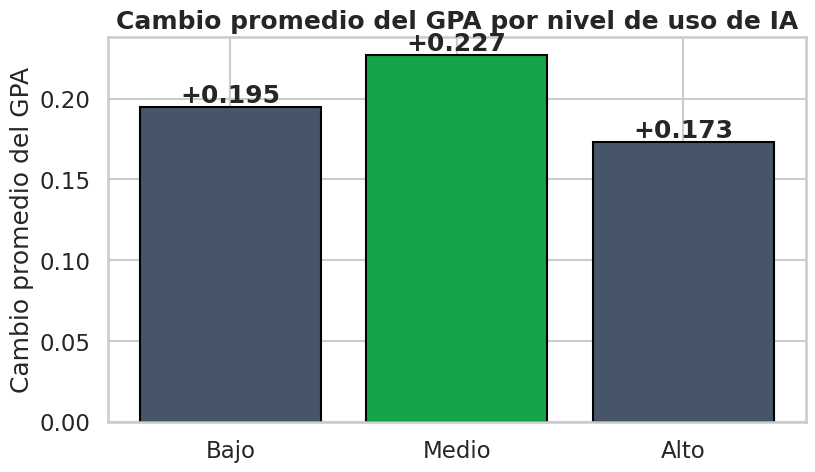

In [17]:
PAL = dict(primario="#2563EB", secundario="#7C3AED",
           exito="#16A34A", peligro="#DC2626",
           alerta="#F59E0B", neutral="#475569")

# Gráfico 1 — Cambio GPA por nivel de uso
fig, ax = plt.subplots(figsize=(9,5))
colors = [PAL["exito"] if x == agg_uso["cambio_gpa"].max() else PAL["neutral"]
          for x in agg_uso["cambio_gpa"]]
ax.bar(agg_uso.index, agg_uso["cambio_gpa"], color=colors, edgecolor="black")
for i, val in enumerate(agg_uso["cambio_gpa"]):
    ax.text(i, val+0.003, f"+{val:.3f}", ha="center", fontweight="bold")
ax.set_title("Cambio promedio del GPA por nivel de uso de IA", fontweight="bold")
ax.set_ylabel("Cambio promedio del GPA")
plt.show()

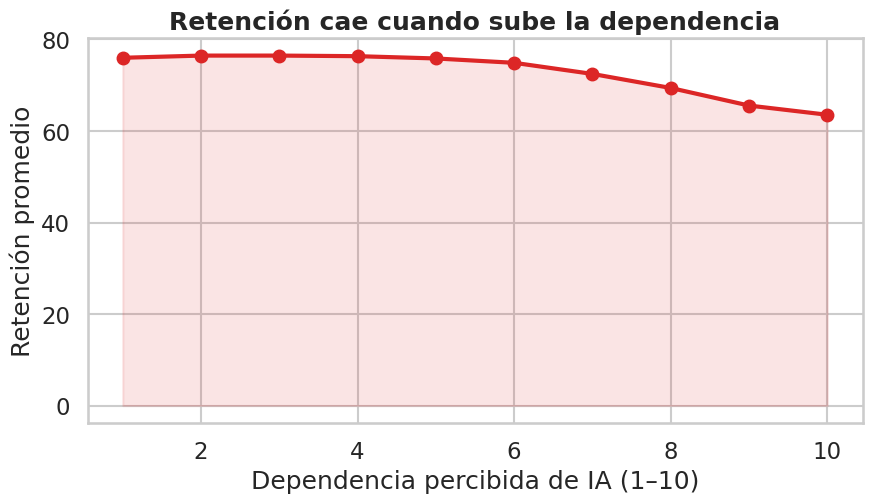

In [18]:
# Gráfico 2 — Retención vs Dependencia
agg_dep = (v.groupby("Perceived_AI_Dependency")["Skill_Retention_Score"]
           .mean().round(2).reset_index())
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(agg_dep["Perceived_AI_Dependency"], agg_dep["Skill_Retention_Score"],
        marker="o", lw=3, color=PAL["peligro"])
ax.fill_between(agg_dep["Perceived_AI_Dependency"], agg_dep["Skill_Retention_Score"],
                color=PAL["peligro"], alpha=0.12)
ax.set_title("Retención cae cuando sube la dependencia", fontweight="bold")
ax.set_xlabel("Dependencia percibida de IA (1–10)")
ax.set_ylabel("Retención promedio")
plt.show()

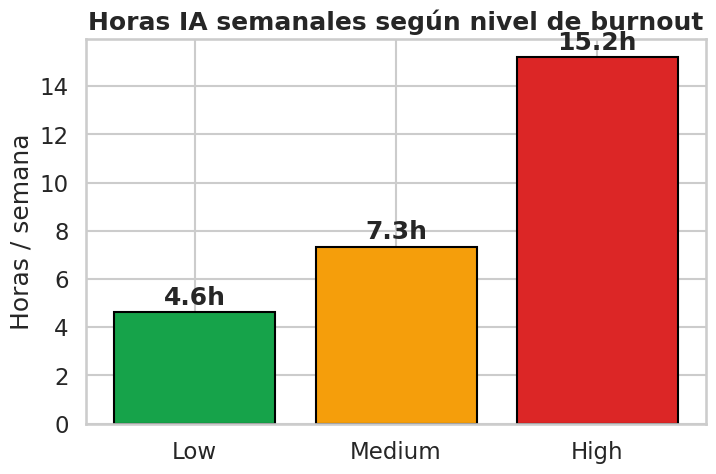

In [19]:
# Gráfico 3 — Horas IA por nivel de burnout
fig, ax = plt.subplots(figsize=(8,5))
col = {"Low":PAL["exito"], "Medium":PAL["alerta"], "High":PAL["peligro"]}
ax.bar(agg_burn["Burnout_Risk_Level"], agg_burn["horas_ia"],
       color=[col[x] for x in agg_burn["Burnout_Risk_Level"]], edgecolor="black")
for i, val in enumerate(agg_burn["horas_ia"]):
    ax.text(i, val+0.3, f"{val:.1f}h", ha="center", fontweight="bold")
ax.set_title("Horas IA semanales según nivel de burnout", fontweight="bold")
ax.set_ylabel("Horas / semana")
plt.show()

## 11. Persistencia del JSON para el dashboard

Las tablas agregadas se serializan a JSON como respaldo liviano para el
dashboard y para futuras consultas sin volver a ejecutar Python.

In [20]:
# tablas agregadas adicionales
agg_anio = (v.groupby(["Year_Encoded","Year_of_Study"])
            .agg(estudiantes=("Student_ID","count"),
                 cambio_gpa=("Cambio_GPA","mean"),
                 retencion=("Skill_Retention_Score","mean"),
                 horas_ia=("Weekly_GenAI_Hours","mean"),
                 riesgo_pct=("Riesgo_Academico", lambda x: 100*x.mean()))
            .round(3).reset_index().sort_values("Year_Encoded"))

agg_caso = (v.groupby("Primary_Use_Case")
            .agg(estudiantes=("Student_ID","count"),
                 cambio_gpa=("Cambio_GPA","mean"),
                 retencion=("Skill_Retention_Score","mean"),
                 horas_ia=("Weekly_GenAI_Hours","mean"))
            .round(3).reset_index().sort_values("cambio_gpa", ascending=False))

dashboard_data = {
    "kpis": kpis,
    "por_nivel_uso":    agg_uso.reset_index().to_dict(orient="records"),
    "por_carrera":      agg_carrera.reset_index().to_dict(orient="records"),
    "por_anio":         agg_anio.to_dict(orient="records"),
    "por_prompting":    agg_prompt.to_dict(orient="records"),
    "por_politica":     agg_pol.to_dict(orient="records"),
    "por_burnout":      agg_burn.to_dict(orient="records"),
    "por_caso_uso":     agg_caso.to_dict(orient="records"),
    "por_dependencia":  agg_dep.assign(retencion=lambda d: d["Skill_Retention_Score"]).drop(columns="Skill_Retention_Score").to_dict(orient="records"),
}
with open(os.path.join(BI, "bi_kpis.json"), "w", encoding="utf-8") as f:
    json.dump(dashboard_data, f, ensure_ascii=False, indent=2, default=float)
print("bi_kpis.json guardado")

bi_kpis.json guardado


## 12. Insights del dashboard

Estos son los cinco hallazgos prioritarios que un decisor debe llevarse del
dashboard. Cada uno está respaldado por los KPIs ya calculados.

### Insight 1 — El uso moderado de IA supera al intensivo
Cambio GPA por nivel: Bajo +0.195, **Medio +0.227**, Alto +0.173. Existe un
punto óptimo de uso; excederlo reduce el valor académico.

### Insight 2 — La dependencia reduce la retención
Retención cae de **76.5 (dependencia 2)** a **63.5 (dependencia 10)** — una
pérdida de 12.5 puntos (16% relativo). Es la curva más nítida del dataset.

### Insight 3 — Burnout y uso intensivo van de la mano
Los estudiantes con burnout High usan **15.21 horas semanales** de IA frente
a **4.64 horas** del grupo Low: una proporción de **3.3×**.

### Insight 4 — Saber promptear pesa más que las horas
Los Advanced mejoran **0.063 puntos más de GPA** que los Beginner. La calidad
del uso de IA importa más que la cantidad.

### Insight 5 — La prohibición no elimina el uso
No hay diferencias significativas de horas entre Strict_Ban y Actively_
Encouraged. Prohibir no funciona; formar en uso reflexivo sí.

## 13. Conclusiones de la fase 3

La fase 3 dejó listo el andamiaje analítico que une el trabajo de ETL/EDA con
el modelado predictivo y la sustentación final:

1. **Un modelo dimensional completo y validado** — esquema estrella con 1
   tabla de hechos + 4 dimensiones, integridad referencial verificada,
   reglas de negocio escritas y comprobadas en código.
2. **17 KPIs ejecutivos** que cubren volumen, adopción, impacto y riesgo.
3. **8 vistas agregadas** que permiten al dashboard responder preguntas por
   cualquier dimensión sin consultar la tabla cruda.
4. **10 visualizaciones de soporte** en `reports/bi/` listas para el documento
   formal y la presentación.
5. **Un dashboard interactivo en Power BI** (`powerbi/DASHBOARD ZIUVAR.pbix`),
   construido sobre las tablas del modelo y listo para la sustentación.

El siguiente paso de la fase 4 (modelado predictivo) toma estos mismos datos
y le pregunta una cosa diferente: "¿podemos *predecir*, a partir del perfil
y los hábitos del estudiante, si va a terminar en riesgo académico?".